In [1]:
import sys, os
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

# --- robust project root detection ---
CWD = Path.cwd()
PROJECT_ROOT = next((p for p in [CWD] + list(CWD.parents) if (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find PROJECT_ROOT (no 'preprocessing/' directory found in parents).")

# Make imports work + ensure relative paths are consistent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)

from analysis.metabolite_level_analysis import analyse_with_logistic_regression

from analysis.plotter import (
    plot_risk_distribution,
    plot_risk_distribution2
)

from analysis.config import make_default_paths
# dataset root
DATA_DIR = PROJECT_ROOT / "ROSMAP-AD"
paths = make_default_paths(DATA_DIR)
#ppaths = to_preprocessing_paths(paths)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
metabolite_levels_file_path = paths.metabolite_levels_file_path

CWD: /home/bioinformatics/Desktop/alzheimer_analysis/notebooks
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/ROSMAP-AD


In [2]:
from preprocessing import (
    MetaboliteLevelsPreprocessorFactory,
    PathwayPreprocessorFactory,
    ReactionPreprocessorFactory
)

factory = MetaboliteLevelsPreprocessorFactory(metabolite_levels_file_path)
preprocessor = factory.create_preprocessor()
y, risk_scores, sample_ids  = analyse_with_logistic_regression(preprocessor)


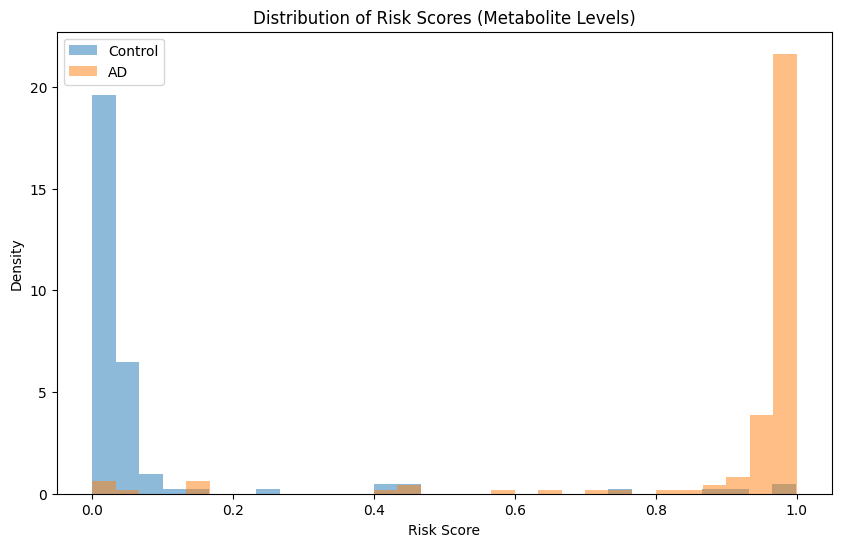

In [3]:
plot_risk_distribution(risk_scores,y,'Metabolite Levels')


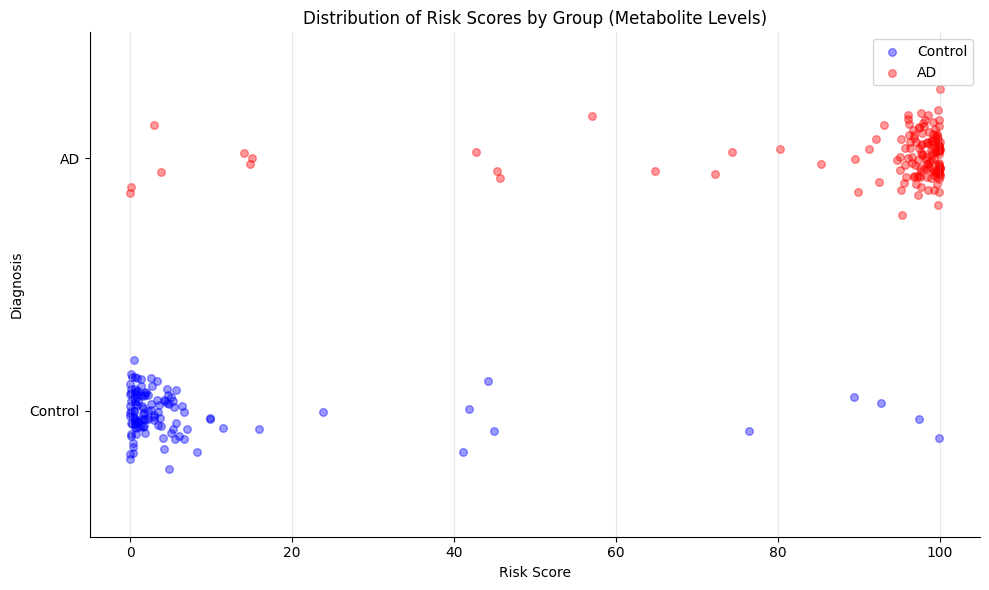

In [4]:
plot_risk_distribution2(risk_scores,y,'Metabolite Levels')
